In [4]:
import pandas as pd
import numpy as np
import re
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

print("--- DATA LOADING ---")
df_calendar = pd.read_csv('data/calendar.csv.zst', compression='zstd')
df_listings = pd.read_csv('data/listings.csv.zst', compression='zstd')

--- DATA LOADING ---


In [5]:
print("--- DATA CLEANING & FEATURE ENGINEERING ---")

def clean_price(price_col):
    return price_col.astype(str).replace(r'[\$,]', '', regex=True).astype(float)

df_calendar['price_clean'] = clean_price(df_calendar['price'])
if 'adjusted_price' in df_calendar.columns:
    df_calendar.drop(columns=['adjusted_price'], inplace=True)

cols_to_keep = [
    'id', 'neighbourhood_cleansed', 'room_type', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'amenities', 
    'review_scores_rating', 'number_of_reviews'
]
cols_to_keep = [c for c in cols_to_keep if c in df_listings.columns]
df_list_sub = df_listings[cols_to_keep].copy()

for col in ['bathrooms', 'bedrooms', 'beds']:
    if col in df_list_sub.columns:
        df_list_sub[col] = df_list_sub[col].fillna(1)

if 'review_scores_rating' in df_list_sub.columns:
    df_list_sub['review_scores_rating'] = df_list_sub['review_scores_rating'].fillna(0)

amenities_series = df_list_sub['amenities'].fillna('')
df_list_sub['has_pool'] = amenities_series.str.contains('pool', flags=re.IGNORECASE).astype(int)
df_list_sub['has_hot_tub'] = amenities_series.str.contains('hot tub|jacuzzi', flags=re.IGNORECASE).astype(int)
df_list_sub['has_ac'] = amenities_series.str.contains('air conditioning|ac', flags=re.IGNORECASE).astype(int)
df_list_sub['has_elevator'] = amenities_series.str.contains('elevator', flags=re.IGNORECASE).astype(int)
df_list_sub['has_parking'] = amenities_series.str.contains('parking|garage', flags=re.IGNORECASE).astype(int)
df_list_sub['has_wifi'] = amenities_series.str.contains('wifi|internet', flags=re.IGNORECASE).astype(int)
df_list_sub['has_kitchen'] = amenities_series.str.contains('kitchen', flags=re.IGNORECASE).astype(int)

df_list_sub['luxury_score'] = df_list_sub['has_pool'] + df_list_sub['has_hot_tub'] + df_list_sub['has_ac'] + df_list_sub['has_elevator']
df_list_sub.drop(columns=['amenities'], inplace=True)

abt = pd.merge(df_calendar, df_list_sub, left_on='listing_id', right_on='id', how='inner')
abt.drop(columns=['id', 'price'], inplace=True)

if 'room_type' in abt.columns:
    abt = pd.get_dummies(abt, columns=['room_type'], drop_first=True, dtype=int)

if 'neighbourhood_cleansed' in abt.columns:
    top_neighborhoods = abt['neighbourhood_cleansed'].value_counts().nlargest(15).index
    abt['neighbourhood_grouped'] = np.where(abt['neighbourhood_cleansed'].isin(top_neighborhoods), abt['neighbourhood_cleansed'], 'Other')
    abt = pd.get_dummies(abt, columns=['neighbourhood_grouped'], drop_first=True, prefix='nh', dtype=int)
    abt.drop(columns=['neighbourhood_cleansed'], inplace=True)

print(f"ABT Shape: {abt.shape[0]} rows, {abt.shape[1]} columns.")

--- DATA CLEANING & FEATURE ENGINEERING ---
ABT Shape: 528745 rows, 38 columns.


In [6]:
print("--- MODEL TRAINING (ISOLATION FOREST) ---")

features_to_drop = ['listing_id', 'date', 'available']
X = abt.drop(columns=[col for col in features_to_drop if col in abt.columns])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

iso_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
iso_model.fit(X_scaled_df)

abt['anomaly_score'] = iso_model.decision_function(X_scaled_df)
abt['is_anomaly'] = iso_model.predict(X_scaled_df)
abt['is_anomaly'] = abt['is_anomaly'].map({1: 0, -1: 1})

anomalies_count = abt['is_anomaly'].sum()
print(f"Anomalies detected: {anomalies_count}")

--- MODEL TRAINING (ISOLATION FOREST) ---
Anomalies detected: 5270


--- EXPLAINABLE AI (SHAP) ---


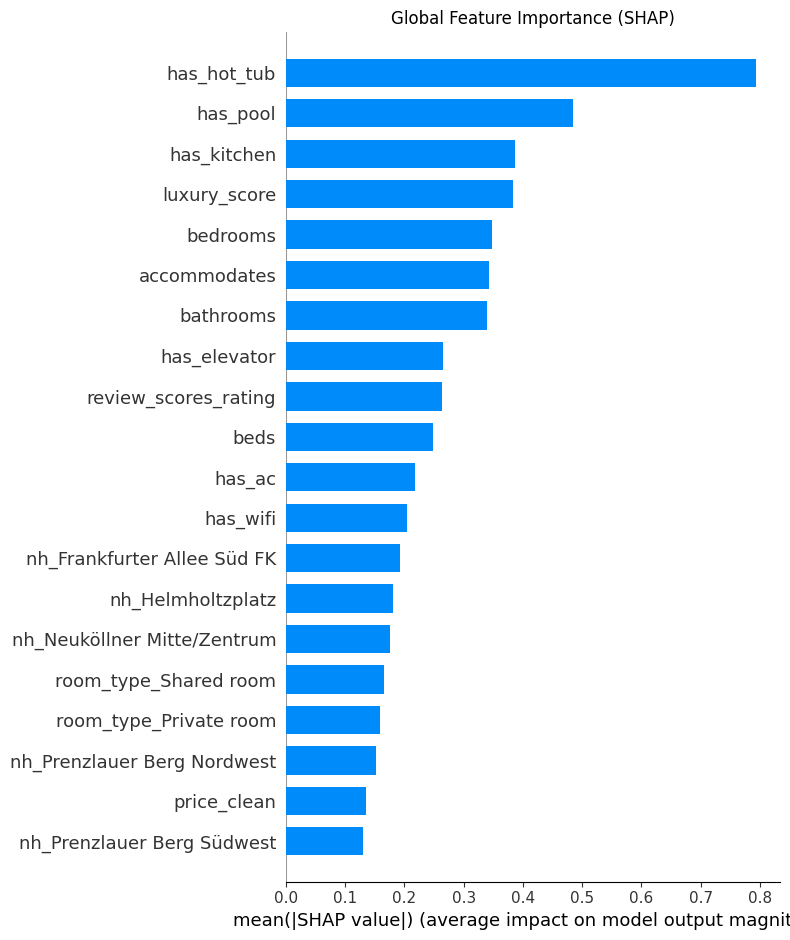

In [7]:
print("--- EXPLAINABLE AI (SHAP) ---")

all_anomalies = X_scaled_df[abt['is_anomaly'] == 1]
explainer = shap.TreeExplainer(iso_model)
shap_values_full = explainer.shap_values(all_anomalies)

plt.figure(figsize=(12, 8))
plt.title("Global Feature Importance (SHAP)")
shap.summary_plot(shap_values_full, all_anomalies, plot_type="bar", feature_names=X.columns, show=False)
plt.tight_layout()
plt.show()

In [8]:
print("--- EXPORTING ARTIFACTS ---")

joblib.dump(iso_model, 'nocarz_iso_model.joblib')
joblib.dump(scaler, 'nocarz_scaler.joblib')
joblib.dump(list(X.columns), 'nocarz_features.joblib')

print("Model, scaler, and features successfully saved.")

--- EXPORTING ARTIFACTS ---
Model, scaler, and features successfully saved.
